# Part A: Customer Segmentation


In [1]:
import pandas as pd 
import numpy as np  

import matplotlib.pyplot as plt  
import seaborn as sns

from sklearn.preprocessing import StandardScaler 
from sklearn.cluster import KMeans  
from sklearn.cluster import AgglomerativeClustering 
from sklearn.mixture import GaussianMixture 

from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score 
from sklearn.metrics import calinski_harabasz_score

from scipy.cluster.hierarchy import dendrogram 
from scipy.cluster.hierarchy import linkage  

In [2]:
# Import customer dataset 
df = pd.read_csv("CA2-Customer-Data.csv")  

df.head()  

,CustomerID,Gender,Age,Income (k$),How Much They Spend
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Exploratory Data Analysis

In [3]:
df.info() # show column names, data types, non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   CustomerID           200 non-null    int64 
 1   Gender               200 non-null    object
 2   Age                  200 non-null    int64 
 3   Income (k$)          200 non-null    int64 
 4   How Much They Spend  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
df.describe()  # show summary statistics for numerical columns 

,CustomerID,Age,Income (k$),How Much They Spend
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
df.isnull().sum()  # check how many missing values exist in each column

CustomerID             0
Gender                 0
Age                    0
Income (k$)            0
How Much They Spend    0
dtype: int64

### Data Visualization

In [6]:
df_numeric = df.drop(columns=["CustomerID"])  # remove CustomerID because it's only an identifier (not useful for clustering)

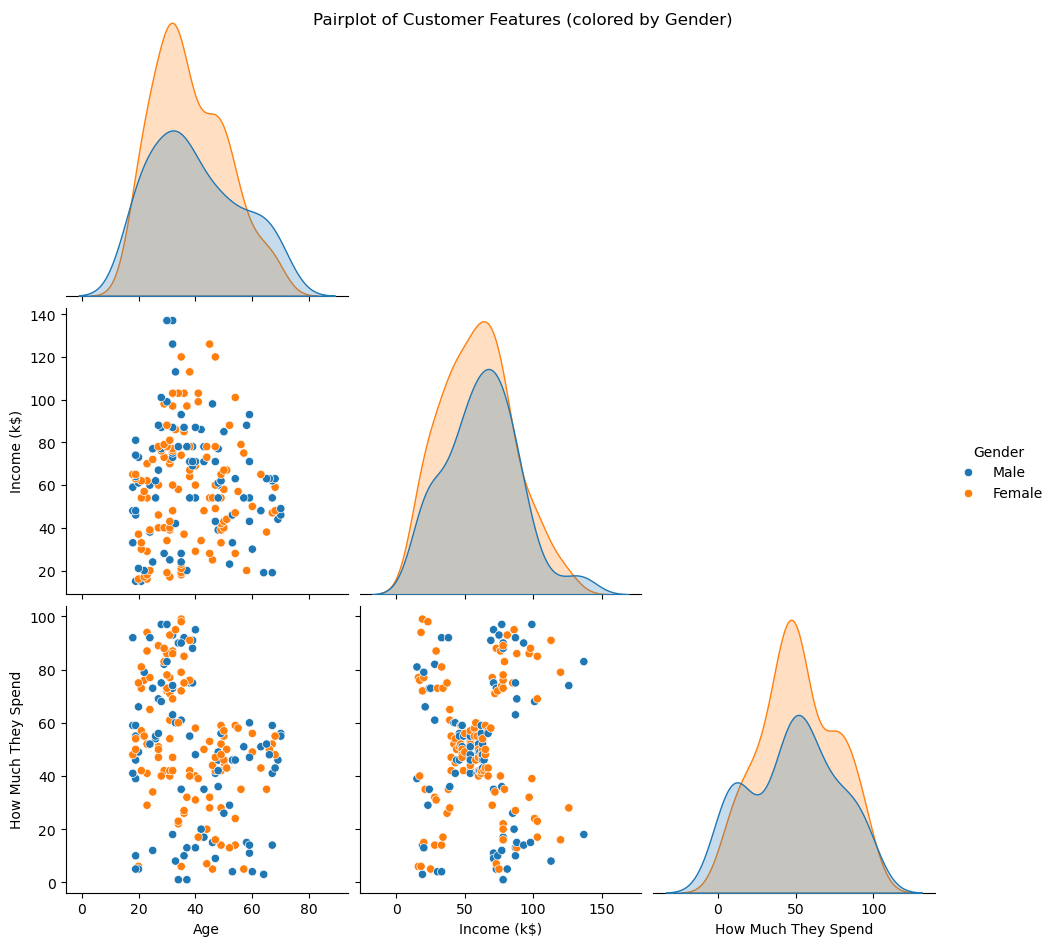

In [7]:
# Create a pairplot:
# - hue="Gender" colors points by Gender to see any visible differences
# - corner=True reduces duplicated plots (only lower triangle)
# - diag_kind="kde" shows a smooth density curve on the diagonal
# - height controls the size of each subplot (bigger = easier to see)
sns.pairplot(
    df_numeric,
    hue="Gender",
    corner=True,
    diag_kind="kde",
    height=3.2
)

plt.suptitle("Pairplot of Customer Features (colored by Gender)")
plt.show()  

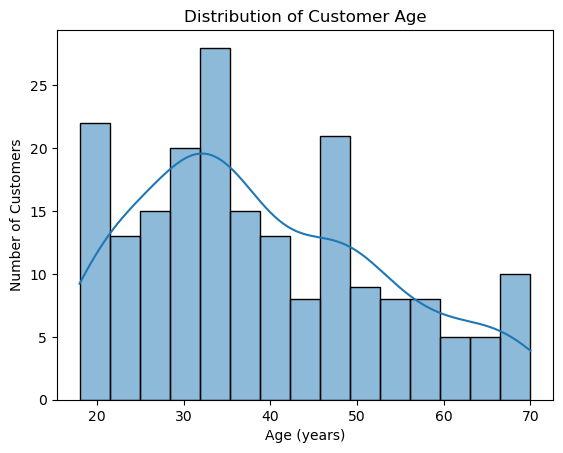

In [8]:
sns.histplot(df["Age"], kde=True, bins=15)

plt.title("Distribution of Customer Age")  
plt.xlabel("Age (years)")  # x-axis label
plt.ylabel("Number of Customers") 
plt.show() 

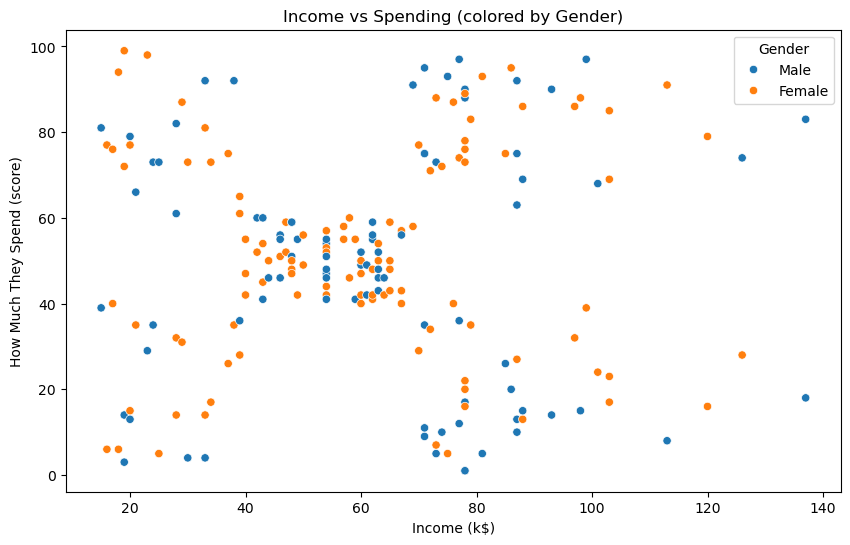

In [9]:
plt.figure(figsize=(10, 6)) 

sns.scatterplot(
    data=df,
    x="Income (k$)",
    y="How Much They Spend",
    hue="Gender"  
)

plt.title("Income vs Spending (colored by Gender)") 
plt.xlabel("Income (k$)")  # x-axis label
plt.ylabel("How Much They Spend (score)")  
plt.legend(title="Gender")  
plt.show()  


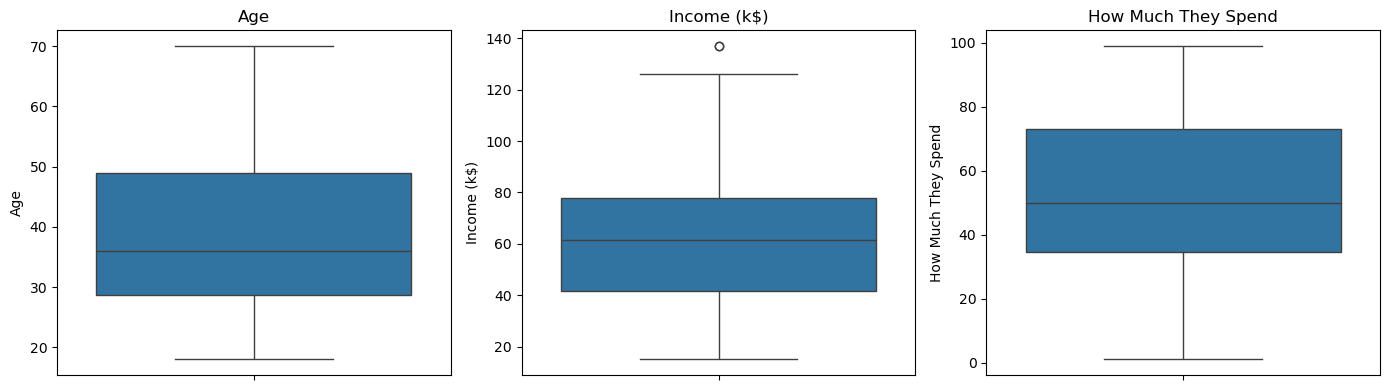

In [10]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)  
sns.boxplot(y=df["Age"])  # boxplot for Age
plt.title("Age")  # subplot title

plt.subplot(1, 3, 2)  
sns.boxplot(y=df["Income (k$)"])  # boxplot for Income
plt.title("Income (k$)")  # subplot title

plt.subplot(1, 3, 3)  
sns.boxplot(y=df["How Much They Spend"])  # boxplot for Spending score
plt.title("How Much They Spend") 

plt.tight_layout()  
plt.show()  


KEY OBSERVATIONS:

1. **Age distribution:**
   - Ages span from 18 to 70, with more customers concentrated in the adult range (roughly late 20s to late 40s).
   - The distribution is not perfectly normal; there are multiple peaks, suggesting different age groups.

2. **Income vs Spending relationship:**
   - There is no strong linear relationship between income and spending.
   - Customers with similar income can have very different spending scores (high spenders exist at both low and high incomes).

3. **Outliers:**
   - Boxplots show an outlier with high income, but they are not so extreme that removal is necessary.
   - Scaling will reduce the effect of different value ranges during clustering.


In [11]:
# We use only numerical features because distance-based clustering needs numeric inputs.
# customerID is removed
# Gender is categorical; we will analyze Gender distribution AFTER clustering.
features = df[["Age", "Income (k$)", "How Much They Spend"]].copy()  

features.head()  

,Age,Income (k$),How Much They Spend
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [12]:
scaler = StandardScaler()  # create a scaler object

X_scaled = scaler.fit_transform(features)  # fit scaler on features and transform them 

X_scaled[:5] 

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992]])

## Feature Engineering

In [13]:
# Spending_Income_Ratio helps identify customers who spend a lot relative to their income.
# (Income is in k$, and spending is a score, so this is a "relative spending intensity" indicator.)
df["Spending_Income_Ratio"] = df["How Much They Spend"] / df["Income (k$)"]

df[["Income (k$)", "How Much They Spend", "Spending_Income_Ratio"]].head()  

,Income (k$),How Much They Spend,Spending_Income_Ratio
0,15,39,2.600000
1,15,81,5.400000
2,16,6,0.375000
3,16,77,4.812500
4,17,40,2.352941


The Spending_Income_Ratio is useful because it captures spending intensity relative to income.

- Two customers may have the same spending score, but if one has low income and the other has high income, their behaviour is very different.
- A higher ratio suggests the customer spends “more aggressively” compared to their income level.
- This helps clustering separate customers into segments like `high spenders with low income` VS `high spenders with high income`, which can lead to different business strategies.

## Data Preprocessing

1. Select features for clustering (numerical columns only)
2. Scale the features using StandardScaler

In [14]:
features = df[["Age", "Income (k$)", "How Much They Spend", "Spending_Income_Ratio"]].copy()  # select columns

scaler = StandardScaler()  # create a new scaler
X_scaled = scaler.fit_transform(features)  # scale the new feature set

X_scaled[:5]  

array([[-1.42456879, -1.73899919, -0.43480148,  1.57724431],
       [-1.28103541, -1.73899919,  1.19570407,  4.46095966],
       [-1.3528021 , -1.70082976, -1.71591298, -0.71427949],
       [-1.13750203, -1.70082976,  1.04041783,  3.85589439],
       [-0.56336851, -1.66266033, -0.39597992,  1.32279884]])

## Model Building

I used three algorithms:
1. **K-Means Clustering** - Fast, works well with spherical clusters
2. **Hierarchical Clustering** - Creates a tree of clusters, doesn't need k specified upfront
3. **Gaussian Mixture Model (GMM)** - Probabilistic approach, flexible cluster shapes

### Determining Optimal Number of Clusters

Methods used to find k:
1. Elbow Method - Plot inertia vs k, look for the "elbow"
2. Silhouette Score - Measures how similar a point is to its cluster vs other clusters


C:\Users\potat\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\potat\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\potat\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\potat\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

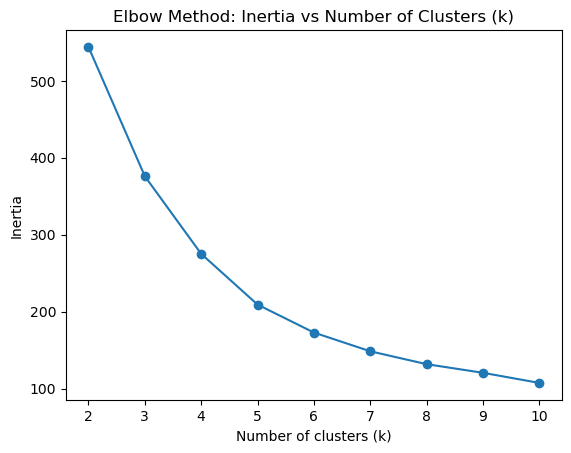

In [15]:
# elbow method
k_values = list(range(2, 11))  # create a list of k values to test (2 to 10 inclusive)
inertias = []  # create an empty list to store inertia values for each k

for k in k_values:  # loop through each possible k
    km = KMeans(n_clusters=k, random_state=42, n_init=10)  # create a KMeans model with k clusters
    km.fit(X_scaled)  # fit the model to the scaled feature data
    inertias.append(km.inertia_)  # store the inertia (sum of squared distances to centroids)

plt.plot(k_values, inertias, marker="o")  
plt.title("Elbow Method: Inertia vs Number of Clusters (k)") 
plt.xlabel("Number of clusters (k)") 
plt.ylabel("Inertia")
plt.xticks(k_values)  
plt.show()

In [16]:
# silhouette score (KMeans)
silhouette_scores = []  # create an empty list to store silhouette scores for each k

for k in k_values:  # loop through each possible k
    km = KMeans(n_clusters=k, random_state=42, n_init=10)  # create a KMeans model
    labels = km.fit_predict(X_scaled)  # fit model and get cluster labels
    score = silhouette_score(X_scaled, labels)  # compute silhouette score
    silhouette_scores.append(score)  # store the score

C:\Users\potat\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\potat\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\potat\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\potat\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

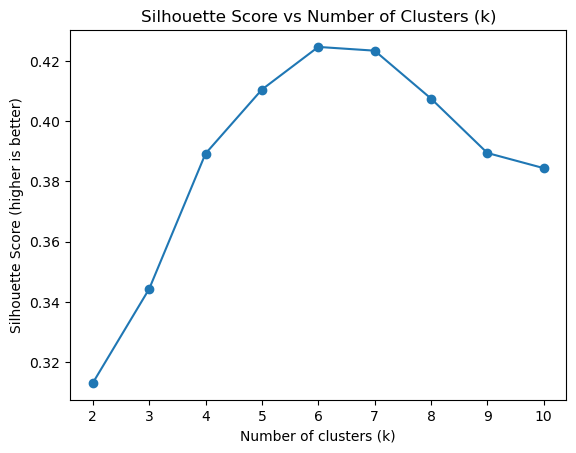

In [17]:
plt.plot(k_values, silhouette_scores, marker="o") 
plt.title("Silhouette Score vs Number of Clusters (k)")  
plt.xlabel("Number of clusters (k)") 
plt.ylabel("Silhouette Score (higher is better)")  
plt.xticks(k_values)  
plt.show()  

In [18]:
# Print the best k from silhouette analysis
best_k = k_values[int(np.argmax(silhouette_scores))]  # find k that gives maximum silhouette score
best_k, max(silhouette_scores)  # output best k and its score

(6, 0.4246056039853127)

Based on the Elbow Method and Silhouette Score:

- Elbow Method: k = 6 (after k=6 the inertia reduction becomes smaller and the curve starts to flatten).
- Silhouette Score is highest at: k = 6 

My chosen optimal number of clusters: k = 6 (supported by both methods).


### K-Means Clustering

In [19]:
kmeans_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)  # create KMeans model
kmeans_labels = kmeans_model.fit_predict(X_scaled)  # fit model and get cluster labels

df["KMeans_Cluster"] = kmeans_labels  # store cluster labels back into the main DataFrame for analysis

df[["CustomerID", "Age", "Income (k$)", "How Much They Spend", "Spending_Income_Ratio", "KMeans_Cluster"]].head()  # preview

C:\Users\potat\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,CustomerID,Age,Income (k$),How Much They Spend,Spending_Income_Ratio,KMeans_Cluster
0,1,19,15,39,2.600000,3
1,2,21,15,81,5.400000,3
2,3,20,16,6,0.375000,1
3,4,23,16,77,4.812500,3
4,5,31,17,40,2.352941,3


### Hierarchical Clustering

In [20]:
agg_model = AgglomerativeClustering(
    n_clusters=best_k,  # use the same k for fair comparison
    linkage="ward"  # ward linkage minimizes variance within clusters 
)

agg_labels = agg_model.fit_predict(X_scaled)  # fit the model and get labels

df["Hierarchical_Cluster"] = agg_labels  # add hierarchical cluster labels to the DataFrame

df[["CustomerID", "Hierarchical_Cluster"]].head() 

,CustomerID,Hierarchical_Cluster
0,1,0
1,2,0
2,3,5
3,4,0
4,5,0


### Gaussian Mixture Model (GMM) Clustering

In [21]:
gmm_model = GaussianMixture(
    n_components=best_k,  # number of clusters
    random_state=42,  # fixed seed for reproducibility
    covariance_type="full"  # full covariance allows ellipsoidal clusters
)

gmm_labels = gmm_model.fit_predict(X_scaled)  # fit model and predict cluster labels

df["GMM_Cluster"] = gmm_labels  # add GMM cluster labels to the DataFrame

df[["CustomerID", "GMM_Cluster"]].head()  

C:\Users\potat\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,CustomerID,GMM_Cluster
0,1,5
1,2,2
2,3,0
3,4,2
4,5,5


## Model Evaluation

In [22]:
results = []  # list to store metric results for each model

# Create a list of (model_name, labels_column_name) to evaluate in a loop
models_to_compare = [
    ("K-Means", "KMeans_Cluster"),
    ("Hierarchical", "Hierarchical_Cluster"),
    ("GMM", "GMM_Cluster")
]

for model_name, labels_col in models_to_compare:  # loop through each model
    labels = df[labels_col]  # get the cluster labels from the DataFrame
    sil = silhouette_score(X_scaled, labels)  # compute silhouette score (higher is better)
    db = davies_bouldin_score(X_scaled, labels)  # compute Davies-Bouldin score (lower is better)
    ch = calinski_harabasz_score(X_scaled, labels)  # compute Calinski-Harabasz score (higher is better)

    results.append({  # store results as a dictionary for easy conversion to DataFrame
        "Model": model_name,
        "Silhouette Score": sil,
        "Davies-Bouldin Score": db,
        "Calinski-Harabasz Score": ch
    })

results_df = pd.DataFrame(results)
results_df  

,Model,Silhouette Score,Davies-Bouldin Score,Calinski-Harabasz Score
0,K-Means,0.424606,0.830636,140.679864
1,Hierarchical,0.404844,0.826620,126.036642
2,GMM,0.366282,0.925944,106.721135


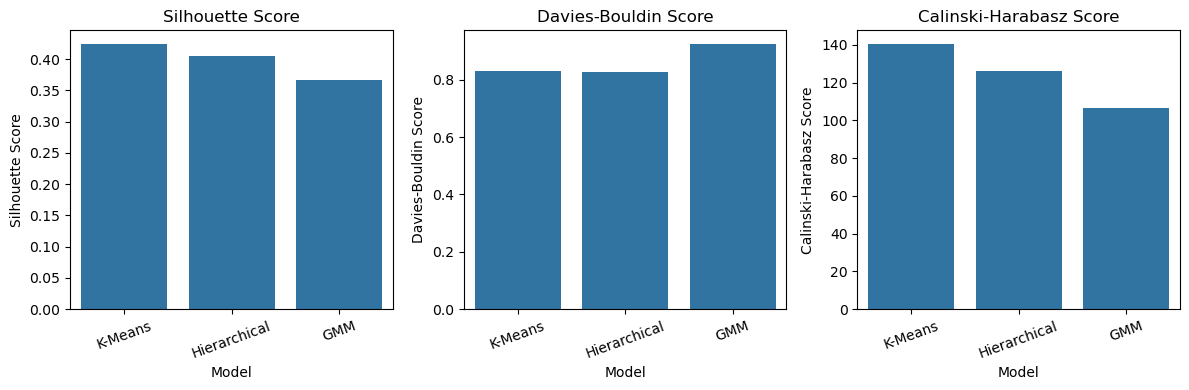

In [23]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)  
sns.barplot(data=results_df, x="Model", y="Silhouette Score") 
plt.title("Silhouette Score")
plt.xticks(rotation=20)  

plt.subplot(1, 3, 2)  
sns.barplot(data=results_df, x="Model", y="Davies-Bouldin Score") 
plt.title("Davies-Bouldin Score") 
plt.xticks(rotation=20)  

plt.subplot(1, 3, 3)  
sns.barplot(data=results_df, x="Model", y="Calinski-Harabasz Score")
plt.title("Calinski-Harabasz Score")  
plt.xticks(rotation=20)  

plt.tight_layout() 
plt.show()  

### Model Comparison Analysis

Three clustering models, K-Means, Hierarchical Clustering, and Gaussian Mixture Model (GMM) were evaluated using Silhouette Score, Davies–Bouldin Score, and Calinski–Harabasz Score to determine the most suitable model for customer segmentation.

1. `Silhouette Score` (Higher is Better)

- K-Means achieved the highest silhouette score, indicating that customers within each cluster are more similar to one another while being well separated from customers in other clusters. Hierarchical clustering performed comparably but slightly lower, while GMM showed weaker cluster separation.

2. `Davies–Bouldin Score` (Lower is Better)

- Hierarchical clustering recorded a marginally lower Davies–Bouldin score than K-Means, suggesting slightly tighter clusters. However, the difference between the two models is small, and both significantly outperform GMM, which shows higher cluster overlap.

3. `Calinski–Harabasz Score` (Higher is Better)

- K-Means produced the highest Calinski–Harabasz score, indicating the clearest separation between clusters relative to within-cluster variance. This suggests that K-Means forms more distinct and well-defined customer groups compared to the other models.

### Overall Comparison

While hierarchical clustering performs competitively across metrics, K-Means demonstrates the strongest overall performance, achieving the best results in two out of three evaluation metrics. In addition, K-Means is computationally efficient and produces clusters that are easier to interpret and visualise.

### Final Model Selection

K-Means is selected as the final model for further visualisation and analysis as it provides the most balanced combination of cluster quality, separation, and interpretability.

## Cluster Visualization


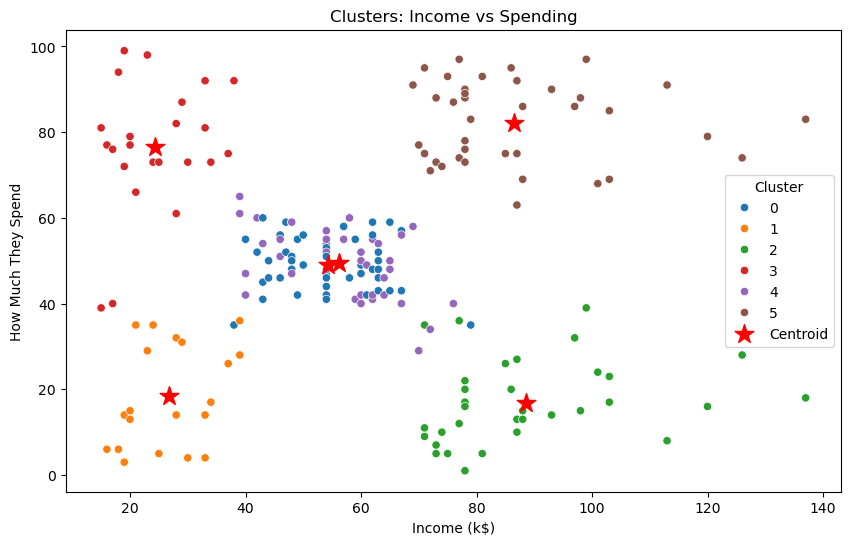

In [24]:
best_labels_col = "KMeans_Cluster" # best model

# Get centroids from trained KMeans model
centroids_scaled = kmeans_model.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)

# Get correct feature indices
feature_names = features.columns.tolist()
income_idx = feature_names.index("Income (k$)")
spend_idx = feature_names.index("How Much They Spend")

plt.figure(figsize=(10, 6))  
sns.scatterplot(
    data=df,
    x="Income (k$)",
    y="How Much They Spend",
    hue=best_labels_col,
    palette="tab10"
)

# Overlay centroids on the existing plot
plt.scatter(
    centroids[:, income_idx],
    centroids[:, spend_idx],
    c="red",
    s=200,
    marker="*",
    label="Centroid"
)

plt.title("Clusters: Income vs Spending") 
plt.xlabel("Income (k$)")  
plt.ylabel("How Much They Spend")  
plt.legend(title="Cluster")
plt.show() 

#### Clusters: Income vs Spending

This chart shows how customers are grouped based on their income level and spending behaviour.

High income customers are separated into both high-spending and low-spending clusters, indicating that income alone does not determine spending behaviour. Some customers with high income spend conservatively, while others spend significantly more.

Lower income customers also form separate clusters, with some showing moderate to high spending despite having lower income. This suggests that factors beyond income, such as lifestyle or preferences, influence spending habits.

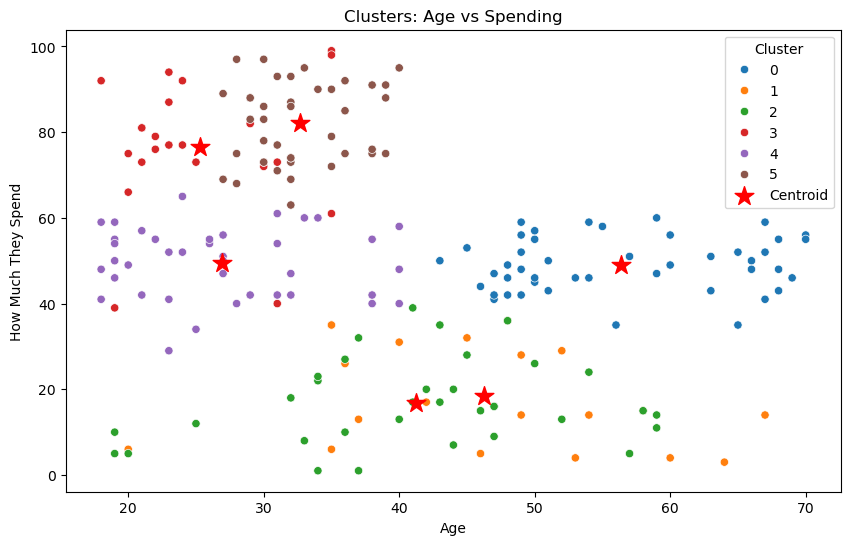

In [25]:
age_idx = feature_names.index("Age")
spend_idx = feature_names.index("How Much They Spend")

plt.figure(figsize=(10, 6))  
sns.scatterplot(
    data=df,
    x="Age",
    y="How Much They Spend",
    hue=best_labels_col,
    palette="tab10"
)

# Overlay centroids on the existing plot
plt.scatter(
    centroids[:, age_idx],
    centroids[:, spend_idx],
    c="red",
    s=200,
    marker="*",
    label="Centroid"
)

plt.title("Clusters: Age vs Spending")  
plt.xlabel("Age")  
plt.ylabel("How Much They Spend") 
plt.legend(title="Cluster")  
plt.show()  

#### Clusters: Age vs Spending 

This chart shows the relationship between customer age and spending patterns.

Younger customers tend to cluster into both high spending and moderate spending groups, indicating diverse spending habits within this age range. Middle-aged customers show a wider spread, forming clusters across low, medium, and high spending levels.

Older customers are more commonly grouped into moderate or lower spending clusters, with fewer high spending individuals. This suggests that spending behaviour generally stabilises or decreases with age.

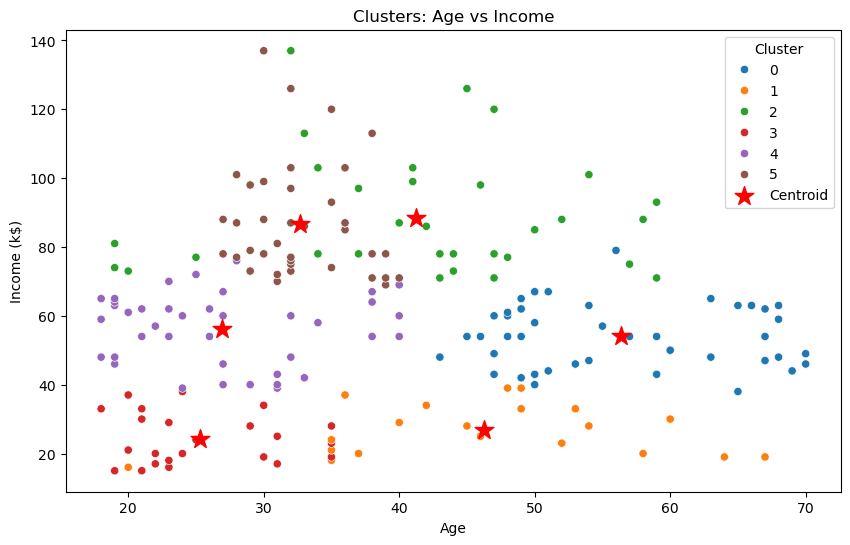

In [26]:
age_idx = feature_names.index("Age")
income_idx = feature_names.index("Income (k$)")

plt.figure(figsize=(10, 6))  
sns.scatterplot(
    data=df,
    x="Age",
    y="Income (k$)",
    hue=best_labels_col,
    palette="tab10"
)

# Overlay centroids on the existing plot
plt.scatter(
    centroids[:, age_idx],
    centroids[:, income_idx],
    c="red",
    s=200,
    marker="*",
    label="Centroid"
)

plt.title("Clusters: Age vs Income")
plt.xlabel("Age")  
plt.ylabel("Income (k$)") 
plt.legend(title="Cluster") 
plt.show()  

#### Clusters: Age vs Income (K-Means)

This chart shows how customers are segmented based on age and income.

Younger customers are mainly concentrated in lower to mid income clusters, while middle aged customers span a wider income range, including several high income clusters. Older customers are spread across mid to high income levels, but form distinct groups separate from younger customers.

The separation of clusters indicates that income generally increases with age up to a point, after which it stabilises. However, customers of similar ages can still have very different income levels, leading to multiple clusters within the same age range.


## Result Analysis: Cluster Characteristics

In [27]:
# Group by cluster and calculate mean values for numeric features.
cluster_profile = df.groupby(best_labels_col)[
    ["Age", "Income (k$)", "How Much They Spend", "Spending_Income_Ratio"]
].mean().round(2)  

cluster_profile  

,Age,Income (k$),How Much They Spend,Spending_Income_Ratio
KMeans_Cluster,,,,
0,56.33,54.27,49.07,0.93
1,46.25,26.75,18.35,0.69
2,41.26,88.50,16.76,0.19
3,25.30,24.30,76.52,3.37
4,26.92,56.21,49.54,0.92
5,32.69,86.54,82.13,0.98


In [28]:
cluster_sizes = df[best_labels_col].value_counts().sort_index()  # count how many customers per cluster
cluster_percent = (cluster_sizes / len(df) * 100)  # convert counts to percentage of total

cluster_summary = pd.DataFrame({  # combine into one table
    "Count": cluster_sizes,
    "Percent (%)": cluster_percent
})

cluster_summary  

,Count,Percent (%)
KMeans_Cluster,,
0,45,22.5
1,20,10.0
2,34,17.0
3,23,11.5
4,39,19.5
5,39,19.5


In [29]:
gender_by_cluster = pd.crosstab(  # create a contingency table of cluster vs gender
    df[best_labels_col],
    df["Gender"],
    normalize="index"  # normalize rows so each cluster sums to 1 (proportions)
).round(3)  # round for readability

gender_by_cluster 

Gender,Female,Male
KMeans_Cluster,,
0,0.578,0.422
1,0.600,0.400
2,0.412,0.588
3,0.565,0.435
4,0.667,0.333
5,0.538,0.462


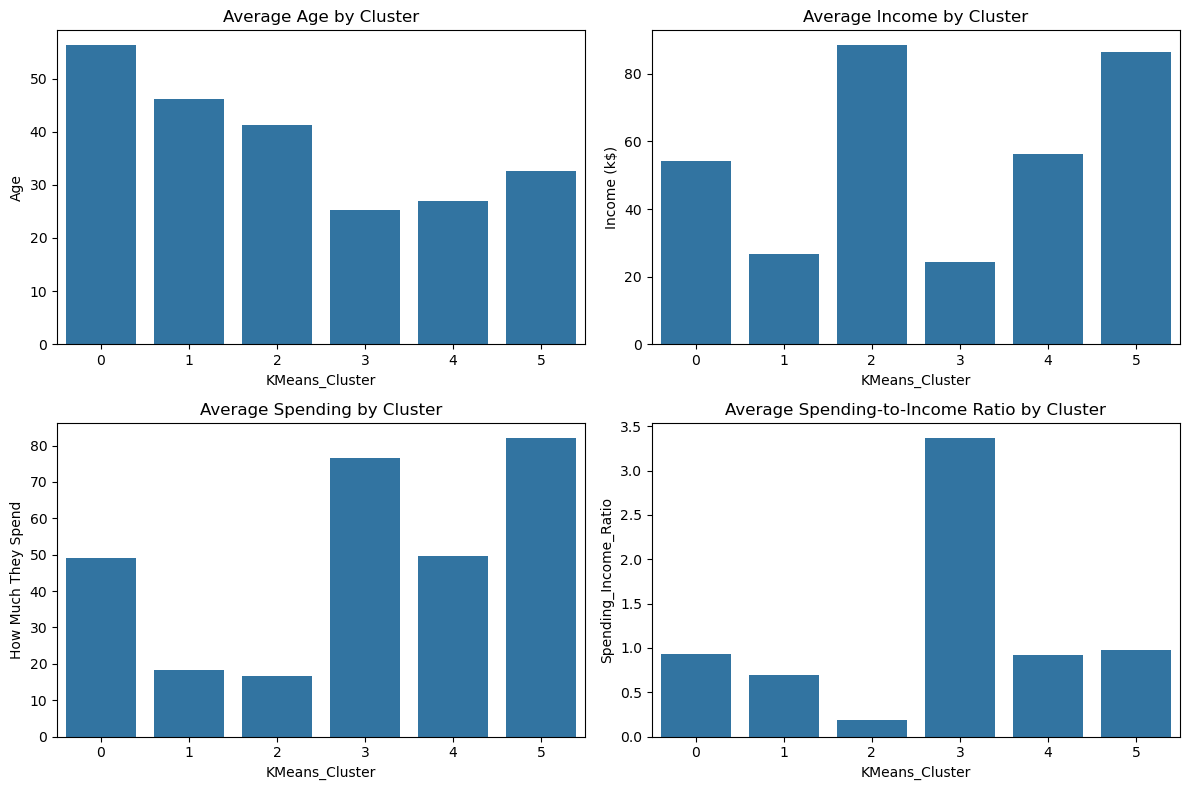

In [30]:
# Reset index to make cluster labels a column for plotting
profile_for_plot = cluster_profile.reset_index() 
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1) 
sns.barplot(data=profile_for_plot, x=best_labels_col, y="Age")
plt.title("Average Age by Cluster")

plt.subplot(2, 2, 2)  
sns.barplot(data=profile_for_plot, x=best_labels_col, y="Income (k$)")
plt.title("Average Income by Cluster")

plt.subplot(2, 2, 3)  
sns.barplot(data=profile_for_plot, x=best_labels_col, y="How Much They Spend")
plt.title("Average Spending by Cluster")

plt.subplot(2, 2, 4) 
sns.barplot(data=profile_for_plot, x=best_labels_col, y="Spending_Income_Ratio")
plt.title("Average Spending-to-Income Ratio by Cluster")

plt.tight_layout() 
plt.show()  

## Result Analysis: Questions

## Question 1: How to perform customer segmentation using an unsupervised machine learning algorithm in Python?

- **Data understanding and exploratory data analysis (EDA)**
  - Load the dataset and check data types, summary statistics, and missing values.
  - Visualise feature distributions and relationships using histograms, boxplots, pairplots, and scatter plots to understand customer behaviour patterns.

- **Feature engineering**
  - Create a new feature, **Spending_Income_Ratio**, to capture spending intensity relative to income.
  - This provides additional behavioural insight beyond raw income and spending values.

- **Feature selection**
  - Select relevant numerical features related to customer behaviour, such as:
    - Age  
    - Income (k$)  
    - How Much They Spend  
    - Spending_Income_Ratio
  - Remove **CustomerID** as it is only an identifier.
  - Retain **Gender** for post-cluster interpretation, but exclude it from model training.

- **Data preprocessing (scaling)**
  - Apply **StandardScaler** to standardise all numerical features.
  - This ensures that no single feature dominates the distance calculations used in clustering algorithms.

- **Model building**
  - Build multiple unsupervised clustering models, including:
    - K-Means  
    - Hierarchical (Agglomerative) Clustering  
    - Gaussian Mixture Model (GMM)

- **Choosing the optimal number of clusters**
  - Test values of k from 2 to 10.
  - Use the **Elbow Method** and **Silhouette Score** to evaluate cluster quality.
  - Select **k = 6** based on consistent performance across both methods.
 
- **Model evaluation and selection**
  - Compare models using:
    - Silhouette Score  
    - Davies–Bouldin Score  
    - Calinski–Harabasz Score
  - Selected **K-Means** as the best overall model due to strong cluster separation and interpretability.

- **Cluster interpretation and business insights**
  - Analyse cluster sizes, feature means, and gender distribution.
  - Label each cluster with a meaningful customer segment.
  - Use the segmentation results to support business decision-making and prioritisation of target customer groups.

## Question 2: What are the characteristics of each customer cluster?

Based on the K-Means clustering results (k = 6), six distinct customer segments were identified. The characteristics below are summarised using cluster mean values and interpreted in terms of customer behaviour.


### Cluster 0 – Older, mid-income, moderate spenders
- **Average Age:** ~56 years  
- **Average Income:** ~$54k  
- **Average Spending:** ~49  
- **Spending–Income Ratio:** ~0.93  

**Interpretation:**  
This segment consists of older customers with stable, mid-level income and moderate spending behaviour. Their spending is proportional to income, indicating consistent and predictable purchasing patterns.

### Cluster 1 – Middle age, low-income, low spenders
- **Average Age:** ~46 years  
- **Average Income:** ~$27k  
- **Average Spending:** ~18  
- **Spending–Income Ratio:** ~0.69  

**Interpretation:**  
These customers have limited income and exhibit conservative spending behaviour. This segment is likely to be price-sensitive and less responsive to premium offerings.

### Cluster 2 – Middle age, high-income, low spenders
- **Average Age:** ~41 years  
- **Average Income:** ~$89k  
- **Average Spending:** ~17  
- **Spending–Income Ratio:** ~0.19  

**Interpretation:**  
Despite having high income, this group spends very little relative to their earning power. This suggests a highly conservative or selective spending behaviour, representing potential for targeted upselling strategies.

### Cluster 3 – Young, low-income, high spenders 
- **Average Age:** ~25 years  
- **Average Income:** ~$24k  
- **Average Spending:** ~77  
- **Spending–Income Ratio:** ~3.37  

**Interpretation:**  
This segment shows extremely high spending intensity relative to income. These customers are likely impulsive or lifestyle-driven spenders, making them valuable but potentially risky due to lower financial stability.

### Cluster 4 – Young, mid-income, moderate spenders
- **Average Age:** ~27 years  
- **Average Income:** ~$56k  
- **Average Spending:** ~50  
- **Spending–Income Ratio:** ~0.92  

**Interpretation:**  
These younger customers have growing income and balanced spending habits. They represent a stable segment with potential for long-term value as income increases over time.

### Cluster 5 – Adult, high-income, high spenders 
- **Average Age:** ~33 years  
- **Average Income:** ~$87k  
- **Average Spending:** ~82  
- **Spending–Income Ratio:** ~0.98  

**Interpretation:**  
This is a premium customer segment with both high income and high spending. Their spending is proportional to income, making them ideal targets for premium products and loyalty programmes.

### Overall Insight
The clustering results reveal that customers differ not only by income or age, but also by **spending intensity**. High-income customers are split into both high and low spending groups, highlighting the importance of behavioural segmentation for targeted marketing strategies.


## Question 3: Which group of customers needs more attention?

### Cluster 5 – High-income, high spenders 

This customer group should receive the highest level of attention as they represent the **most valuable customers** to the business.

**Reasons for prioritising this segment:**
- Customers in this cluster have both **high income and high spending**, making them the highest contributors to revenue.
- Retaining these customers can significantly increase long-term profitability through **loyalty programmes**, **VIP perks**, and **personalised recommendations**.
- They are well suited for **upselling and cross-selling** of premium products and bundled offerings.
- Their spending behaviour is consistent and sustainable, indicating strong lifetime customer value.


### Secondary Segment to Monitor: Cluster 3 – Low-income but high spenders 

This segment also deserves attention, but with a different strategy.

**Reasons for monitoring this segment:**
- These customers spend heavily relative to their income, showing strong engagement and interest in products.
- They may respond well to **targeted promotions**, **entry-level bundles**, or **limited-time offers.**
- However, due to lower income levels, they are likely to be **more price-sensitive**, so incentives should be carefully designed to avoid over-discounting.


### Conclusion
Cluster 5 should be the primary focus due to its high and stable revenue potential, while Cluster 3 represents an opportunity segment that can be nurtured with carefully targeted marketing strategies.
